# SpatioEv Tutorial 02: Scimap Subset Prior-Knowledge Phenotyping

This notebook runs Scimap prior-knowledge phenotyping inside SpatioEv for selected broad populations from the clustering-based phenotyping tutorial:

1. Load manual marker gates, subtype phenotype workflow tables, and `annotation_level1` labels.
2. Rescale the full AnnData once with Scimap's gate-aware rescaling.
3. Subset `fibroblast` and `immune` cells from `annotation_level1`.
4. Phenotype each subset with its matching Scimap workflow table.
5. Merge subtype labels back into a combined `scimap_phenotype` column and review the result.

This is intentionally separate from the unsupervised clustering tutorial.


## Setup And Example Data


In [1]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import pandas as pd

import spatioev as sv

ROOT = Path.cwd()
if not (ROOT / "spatioev").exists():
    for candidate in ROOT.parents:
        if (candidate / "spatioev").exists():
            ROOT = candidate
            break

DATA_DIR = ROOT / "data"
BACKGROUND_DIR = ROOT / "background"
RESULT_DIR = ROOT / "results"
RESULT_DIR.mkdir(exist_ok=True)

EXP1_H5AD = DATA_DIR / "exp_1" / "exp_1.h5ad"
MANUAL_GATES_PATH = DATA_DIR / "exp_1" / "manual_gates.csv"
FIBROBLAST_PHENOTYPE_WORKFLOW_PATH = DATA_DIR / "exp_1" / "fibroblast_phenotype_workflow.csv"
IMMUNE_PHENOTYPE_WORKFLOW_PATH = DATA_DIR / "exp_1" / "immune_phenotype_workflow.csv"

CLUSTERING_ANNOTATION_PATH = RESULT_DIR / "phenotyping_annotations.csv"
ANNOTATION_PATH = RESULT_DIR / "scimap_prior_knowledge_annotations.csv"
PHENOTYPED_H5AD = RESULT_DIR / "scimap_prior_knowledge_phenotyped.h5ad"

ORIGINAL_IMAGE_PATH = BACKGROUND_DIR / "OnTIMEr18_n_a_backsub.ome.tif"
if not ORIGINAL_IMAGE_PATH.exists():
    ORIGINAL_IMAGE_PATH = None


ANNOTATION_LEVEL1_KEY = "annotation_level1"
PHENOTYPE_KEY = "scimap_phenotype"
FIBROBLAST_PHENOTYPE_KEY = "scimap_fibroblast_phenotype"
IMMUNE_PHENOTYPE_KEY = "scimap_immune_phenotype"

SUBTYPE_WORKFLOW_PATHS = {
    "fibroblast": FIBROBLAST_PHENOTYPE_WORKFLOW_PATH,
    "immune": IMMUNE_PHENOTYPE_WORKFLOW_PATH,
}
SUBTYPE_PHENOTYPE_KEYS = {
    "fibroblast": FIBROBLAST_PHENOTYPE_KEY,
    "immune": IMMUNE_PHENOTYPE_KEY,
}


def require_scimap():
    if importlib.util.find_spec("scimap") is None:
        raise ImportError(
            "This notebook requires Scimap for prior-knowledge phenotyping. "
            "Install SpatioEv with `pip install -e '.[viewer]'` or install `scimap[napari]`."
        )
    import scimap as sm
    return sm


def load_example_adata():
    if not EXP1_H5AD.exists():
        raise FileNotFoundError(
            f"Expected real Scimap input AnnData at {EXP1_H5AD}. "
            "This prior-knowledge workflow requires data that match the manual gates and subtype workflow CSVs."
        )

    adata = sv.io.load_h5ad(EXP1_H5AD)
    adata = sv.pp.validate_spatial_coordinates(
        adata,
        x_key="X_centroid",
        y_key="Y_centroid",
        image_key="imageid",
    )
    adata.obs["imageid"] = adata.obs["imageid"].astype(str)
    source = f"local example data: {EXP1_H5AD.relative_to(ROOT)}"
    return adata, source


def workflow_markers(workflow):
    return [col for col in workflow.columns[2:] if not str(col).startswith("Unnamed")]


def align_marker_names(names, reference_names):
    reference_lookup = {str(name).lower(): str(name) for name in reference_names}
    return [reference_lookup.get(str(name).lower(), str(name)) for name in names]


def align_workflow_marker_columns(workflow, reference_names):
    workflow = workflow.copy()
    marker_cols = workflow_markers(workflow)
    aligned = align_marker_names(marker_cols, reference_names)
    workflow = workflow.rename(columns=dict(zip(marker_cols, aligned)))
    return workflow


def load_clustering_annotations(adata, path, annotation_key=ANNOTATION_LEVEL1_KEY):
    if not path.exists():
        raise FileNotFoundError(
            f"Expected clustering annotations at {path}. Run the clustering-based phenotyping notebook first."
        )

    annotations = pd.read_csv(path, index_col=0)
    annotations.index = annotations.index.astype(str)
    if annotations.index.has_duplicates:
        raise ValueError(f"{path} contains duplicate cell IDs.")
    if annotation_key not in annotations.columns:
        raise ValueError(f"{path} must contain {annotation_key!r}.")

    obs_names = pd.Index(adata.obs_names.astype(str))
    missing_cells = obs_names.difference(annotations.index)
    if len(missing_cells):
        preview = ", ".join(missing_cells[:5])
        raise ValueError(f"{path} is missing {len(missing_cells)} AnnData cells, e.g. {preview}.")

    annotations = annotations.loc[obs_names]
    for column in ["cluster_level0", "annotation_level0", annotation_key]:
        if column in annotations.columns:
            adata.obs[column] = annotations[column].astype(str).to_numpy()
    return annotations


def show_counts(series, label):
    counts = series.astype(str).value_counts().rename_axis(label).to_frame("n_cells")
    display(counts.head(30))
    return None


adata, data_source = load_example_adata()
print(f"SpatioEv {sv.__version__}")
print(f"Using {data_source}: {adata.n_obs:,} cells x {adata.n_vars:,} markers")
print("Image IDs:", sorted(adata.obs["imageid"].astype(str).unique()))
print("Original image:", ORIGINAL_IMAGE_PATH if ORIGINAL_IMAGE_PATH else "not found")


SpatioEv 0.1.0
Using local example data: data/exp_1/exp_1.h5ad: 51,932 cells x 25 markers
Image IDs: ['exp']
Original image: /Users/shihongwu/SpatioEv/background/OnTIMEr18_n_a_backsub.ome.tif


## Inspect Scimap Prior-Knowledge Inputs

Load the manual gates, fibroblast/immune subtype workflows, and the `annotation_level1` labels from the clustering-based phenotyping notebook.


In [2]:
manual_gates = pd.read_csv(MANUAL_GATES_PATH)
subtype_workflows = {
    label: pd.read_csv(path)
    for label, path in SUBTYPE_WORKFLOW_PATHS.items()
}
clustering_annotations = load_clustering_annotations(
    adata,
    CLUSTERING_ANNOTATION_PATH,
    annotation_key=ANNOTATION_LEVEL1_KEY,
)

manual_gates["markers"] = align_marker_names(manual_gates["markers"], adata.var_names)
subtype_workflows = {
    label: align_workflow_marker_columns(workflow, adata.var_names)
    for label, workflow in subtype_workflows.items()
}

missing_gate_markers = sorted(set(manual_gates["markers"].astype(str)) - set(adata.var_names))
missing_workflow_markers = {
    label: sorted(set(workflow_markers(workflow)) - set(adata.var_names))
    for label, workflow in subtype_workflows.items()
}
missing_workflow_markers = {
    label: missing
    for label, missing in missing_workflow_markers.items()
    if missing
}
missing_gate_columns = sorted(set(adata.obs["imageid"].astype(str).unique()) - set(manual_gates.columns))
missing_annotation_labels = sorted(
    set(subtype_workflows) - set(adata.obs[ANNOTATION_LEVEL1_KEY].astype(str).unique())
)

print(f"Manual gates: {MANUAL_GATES_PATH.relative_to(ROOT)}")
for label, path in SUBTYPE_WORKFLOW_PATHS.items():
    print(f"{label.title()} phenotype workflow: {path.relative_to(ROOT)}")
print(f"Clustering annotations: {CLUSTERING_ANNOTATION_PATH.relative_to(ROOT)}")
print("Missing gate markers:", missing_gate_markers or "none")
print("Missing workflow markers:", missing_workflow_markers or "none")
print("Missing image gate columns:", missing_gate_columns or "none")
print("Missing annotated populations:", missing_annotation_labels or "none")

display(manual_gates.head())
show_counts(adata.obs[ANNOTATION_LEVEL1_KEY], ANNOTATION_LEVEL1_KEY)

for label, workflow in subtype_workflows.items():
    print(f"{label} phenotype workflow")
    display(workflow.style.format(na_rep=""))

if missing_gate_markers or missing_workflow_markers or missing_gate_columns or missing_annotation_labels:
    raise ValueError("Scimap input tables or clustering annotations are not aligned with this AnnData object.")


Manual gates: data/exp_1/manual_gates.csv
Fibroblast phenotype workflow: data/exp_1/fibroblast_phenotype_workflow.csv
Immune phenotype workflow: data/exp_1/immune_phenotype_workflow.csv
Clustering annotations: results/phenotyping_annotations.csv
Missing gate markers: none
Missing workflow markers: none
Missing image gate columns: none
Missing annotated populations: none


,markers,exp
0,IGFBP5,8.5
1,COL4A1,9.0
2,CD146,7.1
3,RS6,8.8
4,CD31,7.0


,n_cells
annotation_level1,
tumour,24946
immune,15207
fibroblast,4907
artifact,3824
endothelial,3048


fibroblast phenotype workflow


,Unnamed: 0,Unnamed: 1,COL4A1,Vimentin,CD68,PCK,CD3,NaKATPase,CD90,PDPN,Tenascin,COL6A1,SMA,FN,CD45,HLADR,CD11c,CD4,CD14
0,all,myCAFs,neg,,,,,,,,,,pos,,,,,,
1,all,PDPN+ CAFs,neg,,,,,,,pos,,,,,,,,,
2,all,CD90+ CAFs,neg,,,,,,pos,,,,,,,,,,


immune phenotype workflow


,Unnamed: 0,Unnamed: 1,COL4A1,Vimentin,CD68,PCK,CD3,NaKATPase,CD90,PDPN,Tenascin,COL6A1,SMA,FN,CD45,HLADR,CD11c,CD4,CD14
0,all,T cells,,,,,anypos,,,,,,,,,,,,
1,all,Myeloid Lineage,,,anypos,,,,,,,,,,,,anypos,,anypos
2,T cells,CD4 T cells,,,,,,,,,,,,,,,,anypos,
3,Myeloid Lineage,Macrophages,,,anypos,,,,,,,,,,,,,,
4,Myeloid Lineage,Monocytes,,,,,,,,,,,,,,,,,anypos
5,Myeloid Lineage,Dendritic cells,,,,,,,,,,,,,,,anypos,,


## Optional: Define Gates With Scimap/Napari

If you need to create or revise gates, set `RUN_NAPARI_GATER = True`. Otherwise the notebook uses `manual_gates.csv` in the next step.


In [3]:
RUN_NAPARI_GATER = False

if RUN_NAPARI_GATER:
    if ORIGINAL_IMAGE_PATH is None:
        raise FileNotFoundError("Set ORIGINAL_IMAGE_PATH to an OME-TIFF before running Napari gating.")
    adata = sv.tl.scimap_napari_gater(adata, image_path=ORIGINAL_IMAGE_PATH)
else:
    print("Napari gating skipped; using manual_gates.csv.")


Napari gating skipped; using manual_gates.csv.


## Rescale And Subtype With Scimap

Rescale the full AnnData once with manual gates, then phenotype only the `fibroblast` and `immune` cells from `annotation_level1` with their respective subtype workflows. Other cells keep their existing `annotation_level1` labels in the combined Scimap phenotype column.


In [4]:
sm = require_scimap()

# Rescale once with the manual gates, then reuse the rescaled intensities for subset phenotyping.
adata_phenotyped = sv.tl.scimap_rescale(adata.copy(), gate=manual_gates)
adata_phenotyped.obs[PHENOTYPE_KEY] = adata_phenotyped.obs[ANNOTATION_LEVEL1_KEY].astype(str)

subtype_results = {}
for label, workflow in subtype_workflows.items():
    subtype_key = SUBTYPE_PHENOTYPE_KEYS[label]
    adata_phenotyped.obs[subtype_key] = pd.NA

    subset = sv.tl.subset_cells(adata_phenotyped, ANNOTATION_LEVEL1_KEY, label)
    if subset.n_obs == 0:
        print(f"Skipping {label}: no cells in {ANNOTATION_LEVEL1_KEY}.")
        continue

    print(f"Phenotyping {label}: {subset.n_obs:,} cells")
    subset = sv.tl.scimap_phenotype_cells(
        subset.copy(),
        phenotype=workflow,
        label=subtype_key,
    )
    subtype_results[label] = subset

    subtype_values = subset.obs[subtype_key].astype(str)
    adata_phenotyped.obs.loc[subset.obs_names, subtype_key] = subtype_values
    adata_phenotyped.obs.loc[subset.obs_names, PHENOTYPE_KEY] = subtype_values

# Keep the usual SpatioEv/downstream notebook annotation columns in sync.
adata_phenotyped.obs["annotation"] = adata_phenotyped.obs[PHENOTYPE_KEY].astype(str)
adata_phenotyped.obs["annotation_level2"] = adata_phenotyped.obs[PHENOTYPE_KEY].astype(str)
adata_phenotyped.obs["annotated_clusters_update3"] = adata_phenotyped.obs[PHENOTYPE_KEY].astype(str)

print("Combined Scimap phenotypes")
show_counts(adata_phenotyped.obs[PHENOTYPE_KEY], PHENOTYPE_KEY)

for label, subtype_key in SUBTYPE_PHENOTYPE_KEYS.items():
    if label in subtype_results:
        print(f"{label} subtype phenotypes")
        show_counts(subtype_results[label].obs[subtype_key], subtype_key)


Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/scimap/preprocessing/rescale.py:145: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Running GMM for image: exp
Applying GMM to markers: DNA_1

Scaling Image: exp
Scaling DNA_1 (gate: 10.060)
Scaling IGFBP5 (gate: 8.500)
Scaling COL4A1 (gate: 9.000)
Scaling CD146 (gate: 7.100)
Scaling RS6 (gate: 8.800)
Scaling CD31 (gate: 7.000)
Scaling Vimentin (gate: 7.500)
Scaling CD68 (gate: 9.000)
Scaling CD19 (gate: 10.000)
Scaling PCK (gate: 7.400)
Scaling CD3 (gate: 8.000)
Scaling NaKATPase (gate: 9.000)
Scaling COL1A1 (gate: 10.000)
Scaling CD90 (gate: 7.500)
Scaling PDPN (gate: 8.500)
Scaling CK19 (gate: 6.000)
Scaling Tenascin (gate: 9.200)
Scaling COL6A1 (gate: 9.000)
Scaling SMA (gate: 8.400)
Scaling FN (gate: 8.800)
Scaling CD45 (gate: 8.100)
Scaling HLADR (gate: 8.400)
Scaling CD11c (gate: 8.800)
Scaling CD4 (gate: 8.000)
Scaling CD14 (gate: 8.800)
Phenotyping fibroblast: 4,907 cells
Phenotyping myCAFs
Phenotyping PDPN+ CAFs
Phenotyping CD90+ CAFs
Consolidating the phenotypes across all groups
Phenotyping immune: 15,207 cells
Phenotyping T cells
Phenotyping Myeloid Linea

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/scimap/tools/phenotype_cells.py:290: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/scimap/tools/phenotype_cells.py:290: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/scimap/tools/phenotype_cells.py:290: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Combined Scimap phenotypes


,n_cells
scimap_phenotype,
tumour,24946
Unknown,9318
myCAFs,3957
artifact,3824
endothelial,3048
CD4 T cells,2275
Monocytes,1703
Macrophages,932
T cells,924


fibroblast subtype phenotypes


,n_cells
scimap_fibroblast_phenotype,
myCAFs,3957
PDPN+ CAFs,595
Unknown,230
CD90+ CAFs,125


immune subtype phenotypes


,n_cells
scimap_immune_phenotype,
Unknown,9088
CD4 T cells,2275
Monocytes,1703
Macrophages,932
T cells,924
Dendritic cells,285


## Visualize Phenotyping Results


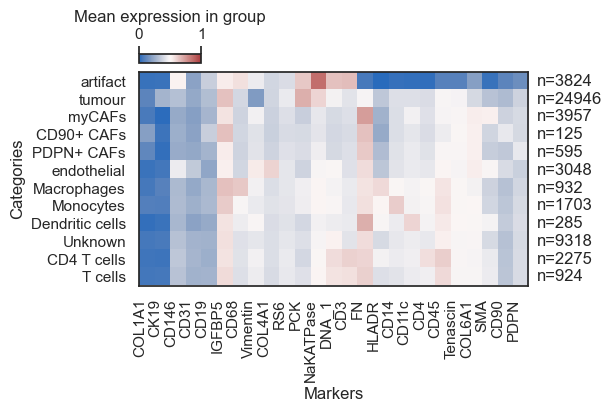

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/scimap/plotting/umap.py:304: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



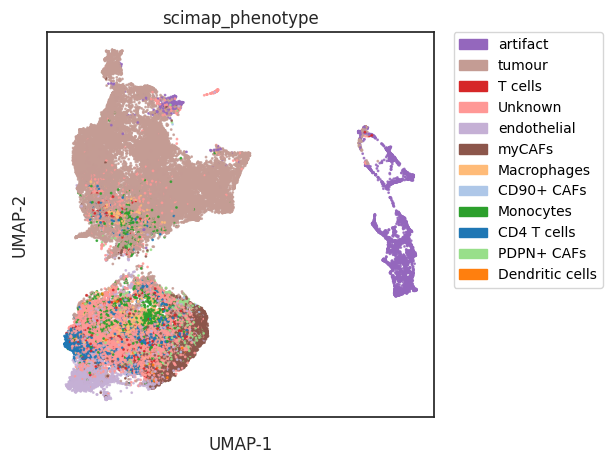

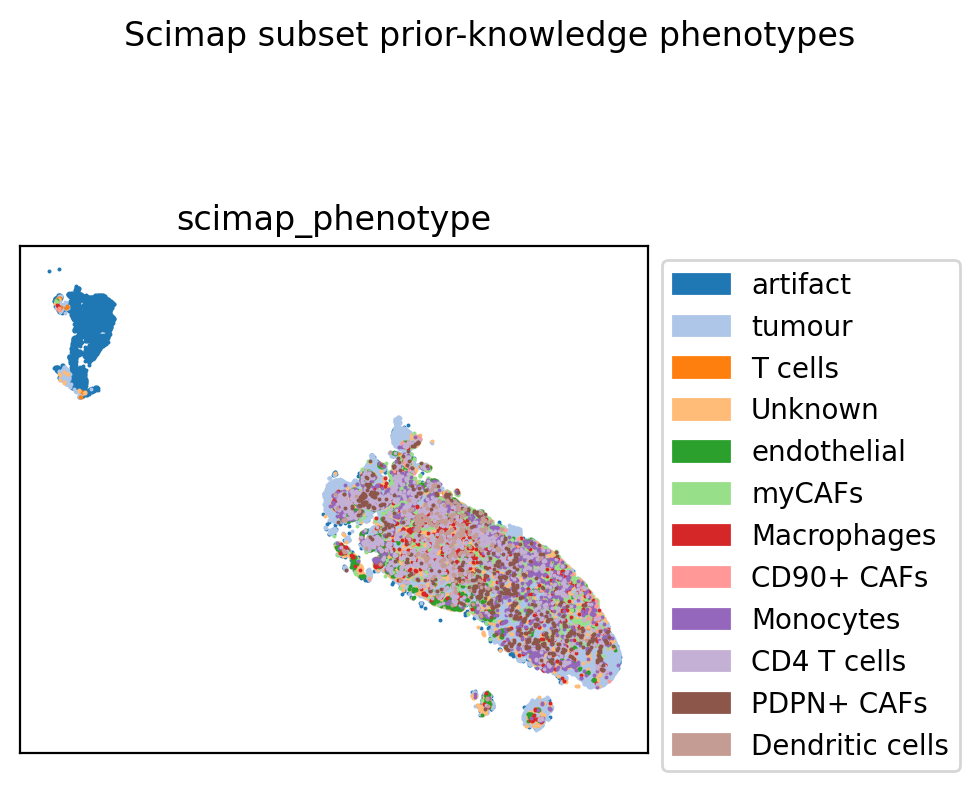

In [5]:
sm.pl.heatmap(
    adata_phenotyped,
    groupBy=PHENOTYPE_KEY,
    standardScale=None,
    figsize=(6, 4),
    showPrevalence=True,
    vmin=0,
    vmax=1,
)
plt.show()
plt.close("all")

try:
    adata_phenotyped = sm.tl.umap(adata_phenotyped)
    sm.pl.umap(adata_phenotyped, color=[PHENOTYPE_KEY], s=1)
    plt.show()
    plt.close("all")
except Exception as exc:
    print(f"Scimap UMAP skipped: {exc}")

sv.pl.spatial_scatter_plot(
    adata_phenotyped,
    colorBy=PHENOTYPE_KEY,
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    imageid="imageid",
    s=2,
    figsize=(5, 5),
)
plt.suptitle("Scimap subset prior-knowledge phenotypes")
plt.show()
plt.close("all")


## Optional: Overlay Phenotypes On The Original Image


In [6]:
RUN_IMAGE_VIEWER = False

if RUN_IMAGE_VIEWER:
    if ORIGINAL_IMAGE_PATH is None:
        raise FileNotFoundError("Set ORIGINAL_IMAGE_PATH before opening the image viewer.")
    sv.pl.inspect_clusters(
        adata_phenotyped,
        image_path=str(ORIGINAL_IMAGE_PATH),
        label=PHENOTYPE_KEY,
        block=True,
    )
else:
    print("Set RUN_IMAGE_VIEWER=True to review phenotypes on the original image.")


Set RUN_IMAGE_VIEWER=True to review phenotypes on the original image.


## Save Scimap Phenotyping Results

Write a Scimap-specific annotation table while preserving the clustering annotations used to select the fibroblast and immune subsets.


In [7]:
annotation_cols = [
    "cluster_level0",
    "annotation_level0",
    ANNOTATION_LEVEL1_KEY,
    FIBROBLAST_PHENOTYPE_KEY,
    IMMUNE_PHENOTYPE_KEY,
    PHENOTYPE_KEY,
    "annotation",
    "annotation_level2",
    "annotated_clusters_update3",
]
annotation_cols = [col for col in annotation_cols if col in adata_phenotyped.obs.columns]
adata_phenotyped.obs[annotation_cols].to_csv(ANNOTATION_PATH)
print(f"Wrote {ANNOTATION_PATH.relative_to(ROOT)}")

SAVE_H5AD = False
if SAVE_H5AD:
    adata_phenotyped.write_h5ad(PHENOTYPED_H5AD, compression="gzip")
    print(f"Wrote {PHENOTYPED_H5AD.relative_to(ROOT)}")


Wrote results/scimap_prior_knowledge_annotations.csv
